In [8]:
import numpy as np
import os
import json
import matplotlib.pyplot as plt
from scipy import stats

In [9]:
def format_all_trajectories(trajectories):
    trajectories = [lst for lst in trajectories if len(lst) > 0]
    # Initialize a list to store the mean values for each key at each step
    mean_values = []
    #Iterate over each step (20 steps)
    for step in range(20):
        step_means = {}
        
        # Iterate over each trajectory
        for trajectory in trajectories:
            for key, values in trajectory[step].items():
                mean = np.mean(np.array(values))
                if key not in step_means:
                    step_means[key] = []
                step_means[key].append(mean)
        
        # Append the dictionary to the mean_values list
        mean_values.append(step_means)

    return mean_values

In [10]:
root_dir = "/vision/asomaya1/active-rir/runs"
fs_rir_errors_path = "intermediate_errors_fs_rir_full.json"
active_rir_errors_path = "intermediate_errors_full.json"
tb_dir = "tb"

#choose which run to visualize:
run = "DDPPO_SD_NA_1500_continuous_all_train_v4"

with open(os.path.join(root_dir, run, tb_dir, fs_rir_errors_path)) as f:
    fs_rir_errors = json.load(f)

with open(os.path.join(root_dir, run, tb_dir, active_rir_errors_path)) as f:
    active_rir_errors = json.load(f)

In [11]:
visualize_single_trajectories = True
active_rir_errors = [lst['metrics'] for lst in active_rir_errors if len(lst) > 0]
episodes = [lst['episode'][1] for lst in fs_rir_errors if len(lst) > 0]
fs_rir_errors = [lst['metrics'] for lst in fs_rir_errors if len(lst) > 0]

In [12]:
len(active_rir_errors[0])

20

In [13]:
if visualize_single_trajectories:
    pass
else:
    active_rir_errors = format_all_trajectories(active_rir_errors)
    fs_rir_errors = format_all_trajectories(fs_rir_errors)

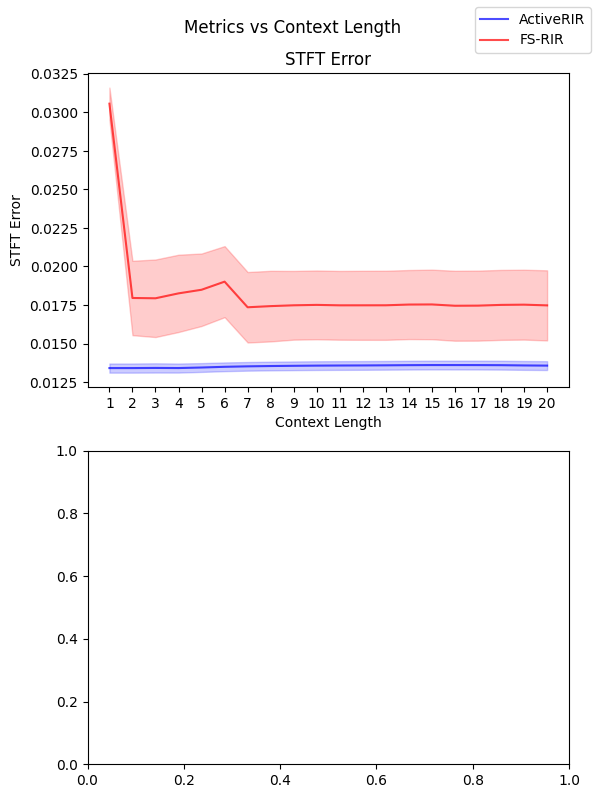

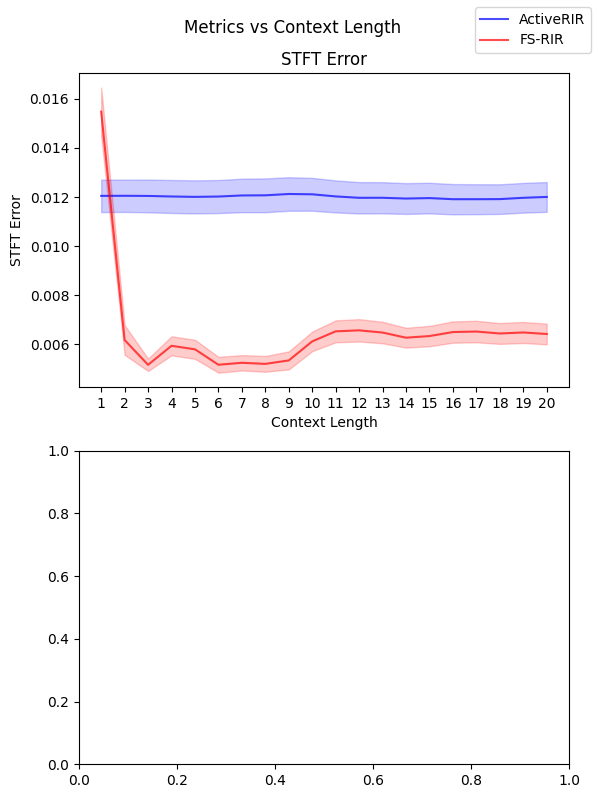

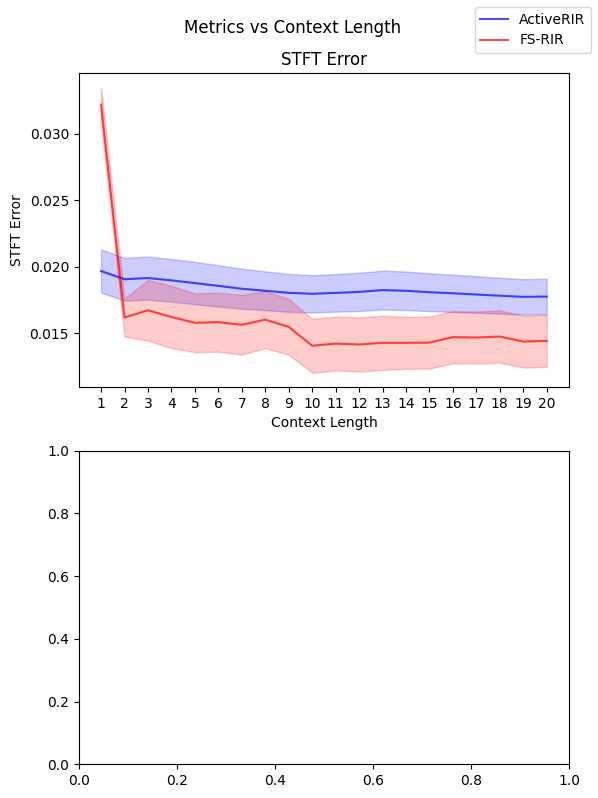

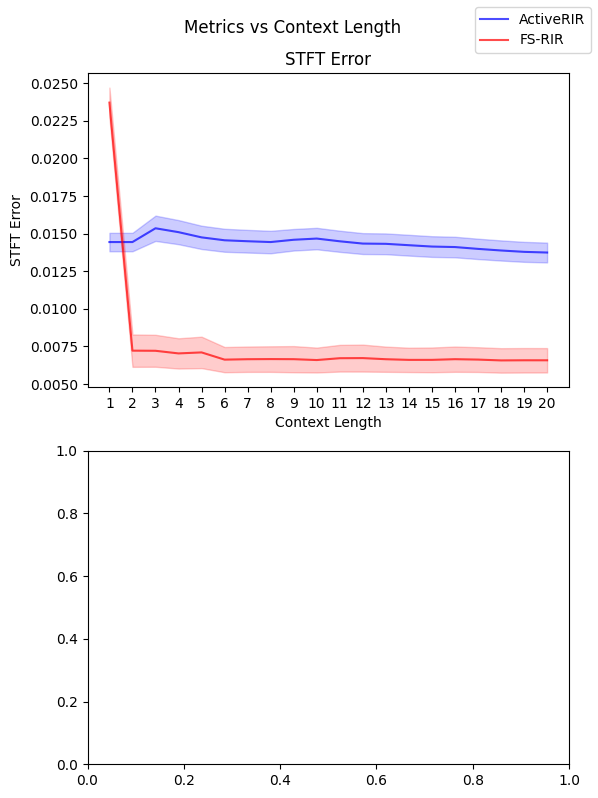

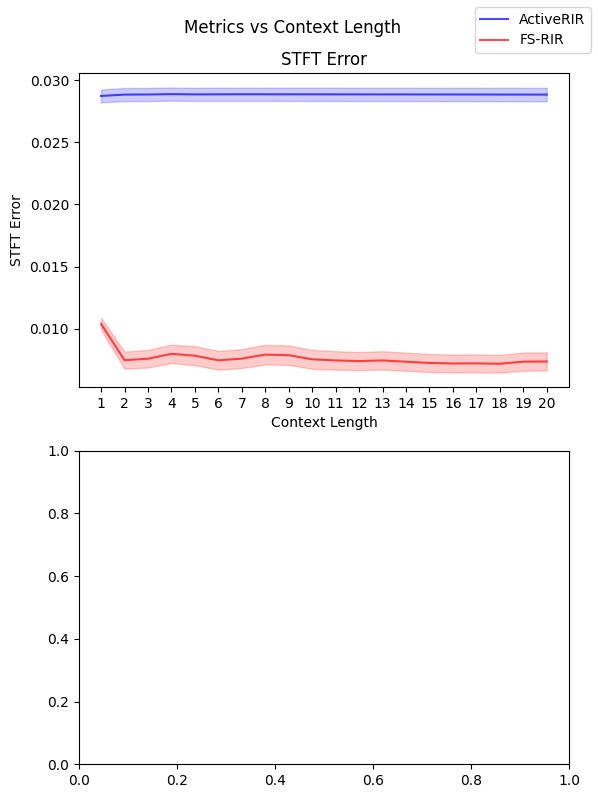

In [14]:
keys_to_plot = ['stft_l1_distance'] #, 'diff_rt_startFrom60dB', 'diff_drr_3ms'
#keys_to_plot = ['stft_l1_distance', 'diff_rt_startFrom60dB', 'rel_diff_rt_startFrom60dB', 'rel_diff_edt', 'diff_drr_3ms', 'rel_diff_drr_3ms']
key_short_names = ['STFT Error', 'RTE', 'Rel RTE', 'EDT', 'DRRE', 'Rel DRRE']

if visualize_single_trajectories:
    for active_error, fsrir_error in zip(active_rir_errors, fs_rir_errors):
        # Extract the keys you want to plot
        

        # Create subplots for each key
        fig, axes = plt.subplots(len(keys_to_plot)+1, figsize=(6, 8))

        legend_labels = []

        # Iterate through the keys and plot each one
        for i, key in enumerate(keys_to_plot):
            # Extract the values for the current key from all dictionaries
            values_active = np.array([np.array(entry[key]) for entry in active_error])
            values_fsrir = np.array([np.array(entry[key]) for entry in fsrir_error])



            # Calculate the mean values and standard deviations at each position
            mean_active_values = np.mean(values_active, axis=-1)
            std_active_values = np.std(values_active, axis=-1) / np.sqrt(len(values_active[0]))

            mean_fsrir_values = np.mean(values_fsrir, axis=-1)
            std_fsrir_values = np.std(values_fsrir, axis=-1)  / np.sqrt(len(values_fsrir[0]))

            # Create the x-axis (positions)
            positions = range(20)

            # Plot the mean line
            active_line, = axes[i].plot(positions, mean_active_values, label=f'ActiveRIR (ours)', color='blue', alpha=0.7)
            fsrir_line, = axes[i].plot(positions, mean_fsrir_values, label=f'FS-RIR', color='red', alpha=0.7)

            # Plot the standard deviation as shaded area
            axes[i].fill_between(positions, mean_active_values - std_active_values, mean_active_values + std_active_values, alpha=0.2, color='blue')
            axes[i].fill_between(positions, mean_fsrir_values - std_fsrir_values, mean_fsrir_values + std_fsrir_values, alpha=0.2, color='red')

            # Customize plot
            axes[i].set_title(f'{key_short_names[i]}')
            axes[i].set_xlabel('Context Length')
            axes[i].set_ylabel(f'{key_short_names[i]}')
            #axes[i].legend()

            # Set x-axis ticks to integers
            axes[i].set_xticks(positions)
            axes[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: int(x+1)))  # Format as integers

        legend_labels.append((active_line, "ActiveRIR"))
        legend_labels.append((fsrir_line, "FS-RIR"))
        fig.legend(*zip(*legend_labels), loc='upper right')
        plt.suptitle('Metrics vs Context Length ')

        # Adjust spacing between subplots
        plt.tight_layout()

        # Show the plots
        plt.show()
else:
    # Extract the keys you want to plot
    #keys_to_plot = ['stft_l1_distance'] #, 'diff_rt_startFrom60dB', 'diff_drr_3ms'
    #key_short_names = ['STFT Error', 'RTE', 'DRRE']

    # Create subplots for each key
    fig, axes = plt.subplots(len(keys_to_plot)+1, figsize=(6, 8))
    legend_labels = []

    # Iterate through the keys and plot each one
    for i, key in enumerate(keys_to_plot):
        # Extract the values for the current key from all dictionaries
        values_active = np.array([np.array(entry[key]) for entry in active_rir_errors])
        values_fsrir = np.array([np.array(entry[key]) for entry in fs_rir_errors])

        # Calculate the mean values and standard deviations at each position
        mean_active_values = np.mean(values_active, axis=-1)
        std_active_values = np.std(values_active, axis=-1) / np.sqrt(len(values_active[0]))

        mean_fsrir_values = np.mean(values_fsrir, axis=-1)
        std_fsrir_values = np.std(values_fsrir, axis=-1)  / np.sqrt(len(values_fsrir[0]))

        # Create the x-axis (positions)
        positions = range(20)

        # Plot the mean line
        active_line, = axes[i].plot(positions, mean_active_values, label=f'ActiveRIR (ours)', color='blue', alpha=0.7)
        fsrir_line, = axes[i].plot(positions, mean_fsrir_values, label=f'FS-RIR', color='red', alpha=0.7)

        # Plot the standard deviation as shaded area
        axes[i].fill_between(positions, mean_active_values - std_active_values, mean_active_values + std_active_values, alpha=0.2, color='blue')
        axes[i].fill_between(positions, mean_fsrir_values - std_fsrir_values, mean_fsrir_values + std_fsrir_values, alpha=0.2, color='red')

        # Customize plot
        axes[i].set_title(f'{key_short_names[i]}')
        axes[i].set_xlabel('Context Length')
        axes[i].set_ylabel(f'{key_short_names[i]}')
        #axes[i].legend()

        # Set x-axis ticks to integers
        axes[i].set_xticks(positions)
        axes[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: int(x+1)))  # Format as integers

    legend_labels.append((active_line, "ActiveRIR"))
    legend_labels.append((fsrir_line, "FS-RIR"))
    fig.legend(*zip(*legend_labels), loc='upper right')
    plt.suptitle('Metrics vs Context Length ')

    # Adjust spacing between subplots
    plt.tight_layout()

    # Show the plots
    plt.show()